# Clasificación de comentarios de cine. Clasificación binaria


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Estilo de las gráficas
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")


En este ejemplo aprenderás a clasificar comentarios de cine en **positivas** y **negativas**, solo a partir del texto de la comentario.

El conjunto de prueba ya viene preprocesado: las comentarios (secuencias de palabras) se han convertido en secuencias de enteros, donde cada entero representa una palabra concreta de un diccionario.


In [2]:
from tensorflow.keras.datasets import imdb

# Cargar comentarios IMDB (num_words=10000 = 10 000 palabras más frecuentes)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)



El argumento `num_words=10000` significa que solo conservamos las **10 000 palabras más frecuentes** en los datos de entrenamiento. Las palabras raras se descartan. Así trabajamos con vectores de tamaño manejable.

Las variables `train_data` y `test_data` son listas de comentarios; cada comentario es una lista de índices de palabras (codifica una secuencia de palabras). `train_labels` y `test_labels` son listas de 0 y 1, donde **0** es **negativo** y **1** es **positivo**:


In [3]:
print("train_data:", type(train_data), train_data.shape)
print("train_labels:", type(train_labels), train_labels.shape)
print("test_data:", type(test_data), test_data.shape)
print("test_labels:", type(test_labels), test_labels.shape)


train_data: <class 'numpy.ndarray'> (25000,)
train_labels: <class 'numpy.ndarray'> (25000,)
test_data: <class 'numpy.ndarray'> (25000,)
test_labels: <class 'numpy.ndarray'> (25000,)


In [4]:
train_data[6]


[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

/tmp/ipykernel_127450/615939726.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Entrenamiento', 'Prueba'])


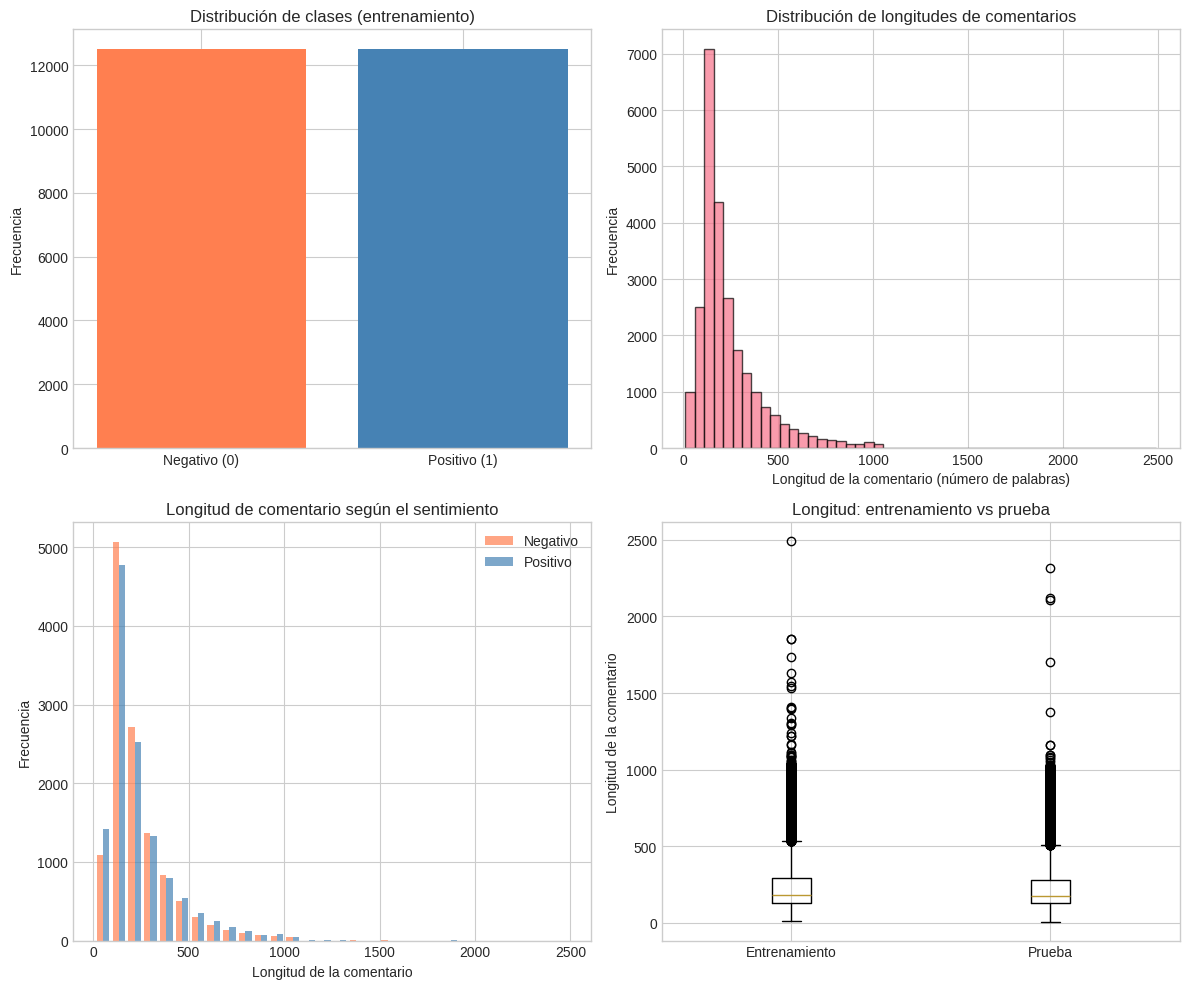

In [5]:
# Exploración visual de los datos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Distribución de clases (positivo vs negativo)
class_counts = pd.Series(train_labels).value_counts().sort_index()
axes[0, 0].bar(['Negativo (0)', 'Positivo (1)'], class_counts.values, color=['coral', 'steelblue'])
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de clases (entrenamiento)')

# 2. Distribución de la longitud de las comentarios
review_lengths = [len(seq) for seq in train_data]
axes[0, 1].hist(review_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Longitud de la comentario (número de palabras)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de longitudes de comentarios')

# 3. Longitud por clase
neg_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 0]
pos_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 1]
axes[1, 0].hist([neg_lengths, pos_lengths], bins=30, label=['Negativo', 'Positivo'], alpha=0.7, color=['coral', 'steelblue'])
axes[1, 0].set_xlabel('Longitud de la comentario')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Longitud de comentario según el sentimiento')
axes[1, 0].legend()

# 4. Entrenamiento vs prueba: comparación de longitud
test_lengths = [len(seq) for seq in test_data]
axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Entrenamiento', 'Prueba'])
axes[1, 1].set_ylabel('Longitud de la comentario')
axes[1, 1].set_title('Longitud: entrenamiento vs prueba')

plt.tight_layout()
plt.show()


Llamaremos **secuencia** a cada texto que representa un comentario. Las secuencias son números que representan palabras distintas. Al limitarnos a las 10 000 palabras más frecuentes, ningún índice supera 10 000 (salvo el token de palabras fuera del vocabulario, que se ignora en la vectorización):


In [6]:
max([max(sequence) for sequence in train_data])


9999

Puedes decodificar rápidamente una de estas comentarios a palabras en inglés:


In [7]:
# word_index: diccionario palabra -> índice entero
word_index = imdb.get_word_index()
print(type(word_index), len(word_index))
# print(word_index.keys())
i = 0
for item in word_index.items():
    print(item)
    i = i + 1
    if(i > 4):
        break



<class 'dict'> 88584
('fawn', 34701)
('tsukino', 52006)
('nunnery', 52007)
('sonja', 16816)
('vani', 63951)


In [8]:
train_data[6]


[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

In [9]:
# Decodificamos las comentarios
# Nota: al crear word_index los índices se desplazan 3 posiciones
# porque 0, 1 y 2 están reservados para relleno, inicio de secuencia y desconocido.
# La comentario con índice 6 se lee en inglés (tras el desplazamiento)

# Creamos el diccionario inverso para decodificar los índices a palabras
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[6]])

In [10]:
decoded_review


"? lavish production values and solid performances in this straightforward adaption of jane ? satirical classic about the marriage game within and between the classes in ? 18th century england northam and paltrow are a ? mixture as friends who must pass through ? and lies to discover that they love each other good humor is a ? virtue which goes a long way towards explaining the ? of the aged source material which has been toned down a bit in its harsh ? i liked the look of the film and how shots were set up and i thought it didn't rely too much on ? of head shots like most other films of the 80s and 90s do very good results"

In [11]:
# Si dudas del desplazamiento de 3, prueba sin él:
decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in train_data[6]])


In [12]:
decoded_review


"the boiled full involving to impressive boring this as murdering naschy br villain and suggestion need has of costumes b message to may of props this and concentrates concept issue skeptical to god's he is and unfolds movie women like isn't surely i'm and to toward in here's for from did having because very quality it is and starship really book is both too worked carl of and br of reviewer closer figure really there will originals things is far this make mistakes and was couldn't of few br of you to don't female than place she to was between that nothing dose movies get are and br yes female just its because many br of overly to descent people time very bland"

## Preparación de los datos


No podemos alimentar la red directamente con `train_data` y `test_data` (listas de enteros). Hay que convertirlas en **tensores**.

- Podríamos **rellenar** (*pad*) las listas para que tengan la misma longitud y obtener un tensor entero de forma `(muestras, índices_palabra)`.
- Podríamos **codificar en one-hot** cada lista como un vector de 0 y 1. Por ejemplo, la secuencia `[3, 5]` se convertiría en un vector de 10 000 dimensiones todo ceros salvo en las posiciones 3 y 5, que serían 1. Entonces la primera capa podría ser una capa `Dense` que procesa vectores en punto flotante.

Vectorizaremos los datos con codificación one-hot.


In [13]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Matriz de ceros de forma (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # p. ej. ponemos 1.0 en la posición 389,
        # si una palabra tiene índice 389 en word_index.
        # modelo bolsa de palabras (se profundizará más adelante)
        results[i, sequence] = 1.  # poner a 1 los índices correspondientes

    return results

# Datos de entrenamiento vectorizados
x_train = vectorize_sequences(train_data)
print("forma de x_train: ", x_train.shape)
# Datos de prueba vectorizados
x_test = vectorize_sequences(test_data)
print("forma de x_test: ", x_test.shape)


forma de x_train:  (25000, 10000)
forma de x_test:  (25000, 10000)


Así lucen las muestras ahora:


In [14]:
x_train.shape


(25000, 10000)

In [15]:
print("len x[0]:", len(x_train[0]),"\n", x_train[0])
print("len x[10000]:", len(x_train[10000]),"\n", x_train[0])


len x[0]: 10000 
 [0. 1. 1. ... 0. 0. 0.]
len x[10000]: 10000 
 [0. 1. 1. ... 0. 0. 0.]


También debemos vectorizar las etiquetas, de forma directa:


In [16]:
# Etiquetas vectorizadas
import numpy as np
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')


In [17]:
print(y_train[0:8])


[1. 0. 0. 1. 0. 0. 1. 0.]


Preparando el terreno (Cargar y Vectorizar)

In [18]:
import numpy as np
from tensorflow.keras.datasets import imdb

# 1. Cargar datos
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

# 2. Función para convertir números a tensores (vectores de 0 y 1)
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# 3. Crear datos de validación (¡ESTO ES VITAL!)
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

Los datos ya están listos para alimentar una red neuronal.


## Construcción de la red


Los datos de entrada son vectores y las etiquetas escalares (0 o 1). Una arquitectura que suele funcionar bien es una pila de capas totalmente conectadas (`Dense`) con activación `relu`, por ejemplo `Dense(16, activation='relu')`.

Cada capa `Dense` con `relu` implementa la cadena:

`salida = relu(dot(W, entrada) + b)`

Con 16 unidades ocultas, la matriz `W` tiene forma `(dimensión_entrada, 16)`; el producto con `W` proyecta los datos a un espacio de 16 dimensiones (luego se suma el sesgo `b` y se aplica `relu`). Aquí la dimensión de entrada es 10 000. Hay 25 000 muestras de dimensión 10 000 cada una.

Hay dos decisiones clave en esta pila densa:

* Cuántas capas usar.
* Cuántas **unidades ocultas** poner en cada capa.

La **sigmoide** comprime valores arbitrarios al intervalo `[0, 1]`, de modo que la salida se interpreta como probabilidad.


### Implementación en Keras:


In [19]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#**Problema 1**

Construyendo y Compilando RMSPROP

In [20]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop', # Requisito del Problema 1
              loss='binary_crossentropy',
              metrics=['accuracy'])

Entrenar y Graficar

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7577 - loss: 0.5669 - val_accuracy: 0.8596 - val_loss: 0.4448
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8855 - loss: 0.3608 - val_accuracy: 0.8750 - val_loss: 0.3353
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9158 - loss: 0.2609 - val_accuracy: 0.8848 - val_loss: 0.2965
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9303 - loss: 0.2075 - val_accuracy: 0.8892 - val_loss: 0.2766
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9455 - loss: 0.1737 - val_accuracy: 0.8882 - val_loss: 0.2755
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9543 - loss: 0.1451 - val_accuracy: 0.8872 - val_loss: 0.2816
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9626 - loss: 0.1226 - val_accuracy: 0.8688 - val_loss: 0.3627
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9691 - loss: 0.1051 - val_accuracy: 0.8644 - v

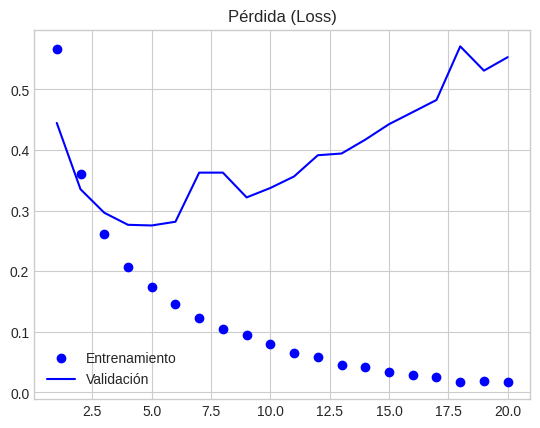

In [21]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

# GRAFICAR PÉRDIDA
import matplotlib.pyplot as plt
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Entrenamiento')
plt.plot(epochs, val_loss, 'b', label='Validación')
plt.title('Pérdida (Loss)')
plt.legend()
plt.show()

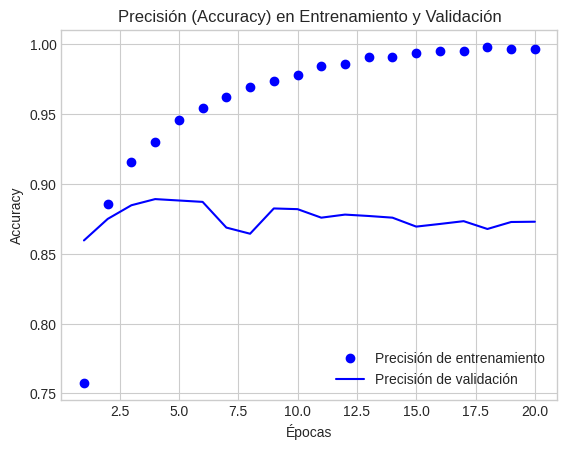

In [22]:
plt.clf() # Borra la gráfica anterior
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Precisión de entrenamiento')
plt.plot(epochs, val_acc, 'b', label='Precisión de validación')
plt.title('Precisión (Accuracy) en Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#**Conclusión**

1.   **Identificación del Punto Óptimo**

Al observar detenidamente las gráficas de pérdida (loss) y precisión (accuracy), se identifica que el modelo alcanza su rendimiento máximo en la época 4. En este punto, logramos una precisión de validación del 88.91% y la pérdida de validación más baja (0.2791). Hasta aquí, el modelo está aprendiendo patrones generales que le permiten clasificar correctamente reseñas que no había visto antes.

2.   **Diagnóstico de Sobreajuste (Overfitting)**
A partir de la época 5, el comportamiento de las curvas se separa drásticamente, lo cual es una señal clara de sobreajuste:

*   **En el entrenamiento:** La precisión sigue subiendo hasta rozar la perfección (99.81% en la época 20) y la pérdida cae casi a cero. Esto indica que la red neuronal está "memorizando" palabra por palabra los comentarios del set de entrenamiento, incluyendo el ruido y detalles irrelevantes.

*  ** En la validación:** La pérdida sube de forma alarmante de 0.2783 a 0.5611. Al subir la pérdida, el modelo se vuelve "menos seguro" de sus predicciones en datos nuevos, confirmando que ha perdido su capacidad de generalización.


3.   **Justificación Técnica**
Este fenómeno ocurre porque el modelo es "demasiado potente" o complejo para la cantidad de datos, y al no tener restricciones, ajusta sus pesos de forma excesiva a los ejemplos de entrenamiento. Como estudiante de Deep Learning, interpreto que dejar el entrenamiento en 20 épocas sin control es contraproducente.

4.   **Recomendaciones:**

*   **Regularización de pesos (L1/L2):** Para penalizar pesos demasiado grandes.
*   **Dropout**: Para forzar a la red a no depender de neuronas específicas y aprender patrones más globales.







Debemos elegir una **función de pérdida** y un **optimizador**. Como es clasificación binaria y la salida es una probabilidad (última capa de 1 unidad con sigmoide), lo habitual es usar `binary_crossentropy`. No es la única opción (por ejemplo `mean_squared_error`), pero la entropía cruzada suele ser la mejor cuando la salida es probabilística.

Aquí configuramos el modelo con optimizador `rmsprop` y pérdida `binary_crossentropy`. También monitorizamos la **precisión** (*accuracy*) durante el entrenamiento.


In [23]:
model.compile(optimizer='rmsprop',   # 'adam' es una alternativa habitual
              loss='binary_crossentropy',
              metrics=['accuracy'])


Podemos pasar optimizador, pérdida y métricas como **cadenas** porque `rmsprop`, `binary_crossentropy` y `accuracy` vienen empaquetados en Keras. A veces conviene configurar el optimizador o usar funciones personalizadas de pérdida o métrica; el primero se hace pasando una **instancia** de optimizador:


In [24]:
from tensorflow.keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


Lo segundo pasando **objetos función** como argumentos `loss` o `metrics`:


In [25]:
from tensorflow.keras import losses
from tensorflow.keras import metrics

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])


## Validación del enfoque

Para comprobar el rendimiento en datos no vistos, creamos un **conjunto de validación** separando **10 000** muestras del entrenamiento original:


In [26]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]


Entrenaremos el modelo durante **20 épocas** (20 pasadas completas sobre `x_train` e `y_train`), con mini-lotes de **512** muestras. Al mismo tiempo monitorizamos pérdida y precisión en las 10 000 muestras reservadas, pasando `validation_data` a `fit`:


In [27]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - binary_accuracy: 0.9967 - loss: 0.0156 - val_binary_accuracy: 0.8682 - val_loss: 0.5730
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - binary_accuracy: 0.9977 - loss: 0.0134 - val_binary_accuracy: 0.8709 - val_loss: 0.5939
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - binary_accuracy: 0.9998 - loss: 0.0058 - val_binary_accuracy: 0.8731 - val_loss: 0.6227
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.9983 - loss: 0.0090 - val_binary_accuracy: 0.8691 - val_loss: 0.6350
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - binary_accuracy: 0.9999 - loss: 0.0040 - val_binary_accuracy: 0.8707 - val_loss: 0.6607
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9979 - loss: 0.0092 - val_binary_accuracy: 0.8690 - val_loss: 0.6766
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - binary_accuracy: 0.9999 - loss: 0.0029 - val_binary_accuracy: 0.8716 - val_loss: 0.7158
Epoch 8/20
30

En CPU, cada época suele tardar menos de dos segundos; en unos 20 segundos termina el entrenamiento. Al final de cada época hay una breve pausa mientras se evalúa en validación.

La llamada a `model.fit()` devuelve un objeto `History` con un diccionario `history` con todo lo ocurrido durante el entrenamiento. Inspeccionémoslo:


In [28]:
history_dict = history.history
history_dict.keys()


dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

Contiene cuatro series: una por métrica monitorizada en entrenamiento y en validación. Usemos Matplotlib para graficar pérdida y precisión de entrenamiento y validación:


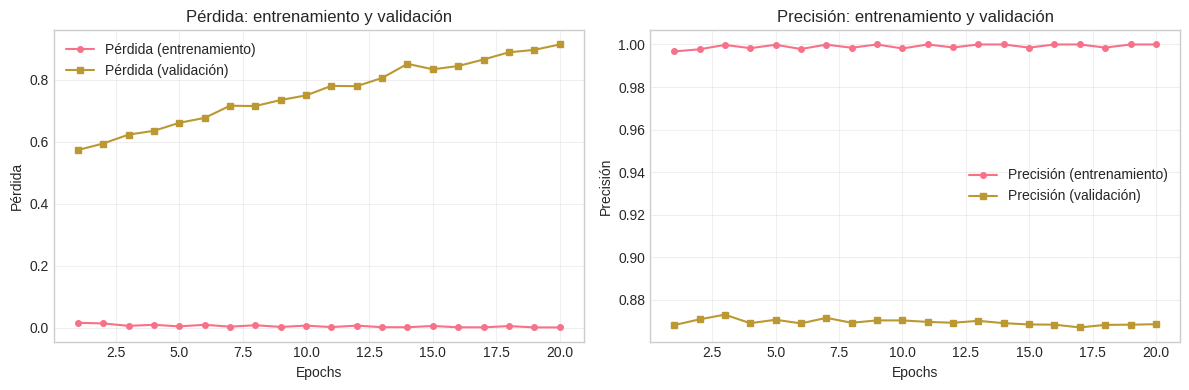

In [29]:
# Historial: pérdida y precisión
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [30]:
# Mejor época (menor pérdida en validación); útil para parada temprana
best_epoch = np.argmin(val_loss) + 1
print(f"Mejor época (menor pérdida en validación): {best_epoch}")


Mejor época (menor pérdida en validación): 1



Los puntos son pérdida y precisión de **entrenamiento**; las líneas continuas, las de **validación**.

La pérdida de entrenamiento baja en cada época y la precisión de entrenamiento sube: es lo esperable con descenso por gradientes. **No** ocurre lo mismo con validación: suelen alcanzar un máximo hacia la cuarta época. Esto ilustra el aviso anterior: un modelo que mejora en entrenamiento no siempre generaliza mejor. En rigor, aparece **sobreajuste** (*overfitting*): tras cierta época optimizamos demasiado el entrenamiento y aprendemos representaciones específicas que no generalizan fuera de él.

Para mitigarlo, podríamos parar tras unas pocas épocas. En general hay muchas técnicas anti-sobreajuste (se verán más adelante).

Entrenemos una red nueva desde cero durante **cuatro** épocas y evaluemos en el conjunto de prueba:


In [31]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)


Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8153 - loss: 0.4484
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9062 - loss: 0.2653
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9254 - loss: 0.2095
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9356 - loss: 0.1792
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8836 - loss: 0.2926


In [32]:
results


[0.2925950288772583, 0.8836399912834167]

Este enfoque relativamente simple alcanza alrededor del **88 %** de precisión. Con métodos más avanzados se puede acercar al **95 %**.


## Usar la red entrenada para predecir datos nuevos

Tras entrenar, interesa desplegar el modelo. La probabilidad de que una comentario sea positiva se obtiene con `predict`:


In [33]:
# Predicciones (probabilidades)
predictions = model.predict(x_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


### Visualización de la evaluación del modelo

A continuación se visualizan las predicciones: matriz de confusión, curva ROC, distribución de probabilidades y aciertos frente a errores.


Como ves, la red es muy segura en algunas muestras (0,99 o más, o 0,01 o menos) y menos segura en otras (0,6, 0,4).


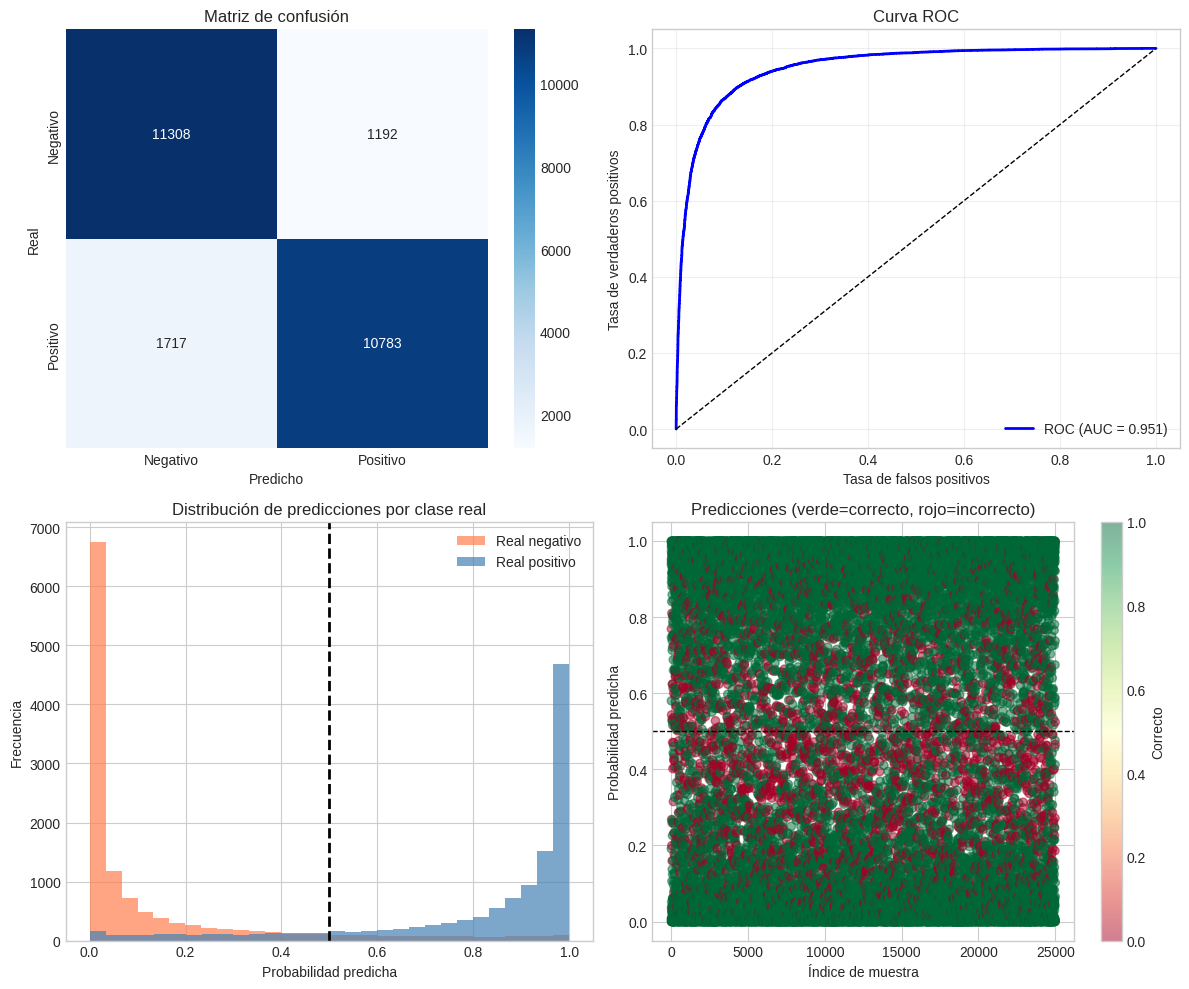

In [34]:
# Visualización de predicciones
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
axes[0, 0].set_xlabel('Predicho')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_title('Matriz de confusión')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('Tasa de falsos positivos')
axes[0, 1].set_ylabel('Tasa de verdaderos positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de probabilidades predichas por clase real
axes[1, 0].hist(predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Real negativo', color='coral')
axes[1, 0].hist(predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Real positivo', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Probabilidad predicha')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de predicciones por clase real')
axes[1, 0].legend()

# 4. Predicciones correctas vs incorrectas
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(predictions)), predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Índice de muestra')
axes[1, 1].set_ylabel('Probabilidad predicha')
axes[1, 1].set_title('Predicciones (verde=correcto, rojo=incorrecto)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correcto')

plt.tight_layout()
plt.show()


# Regularizers

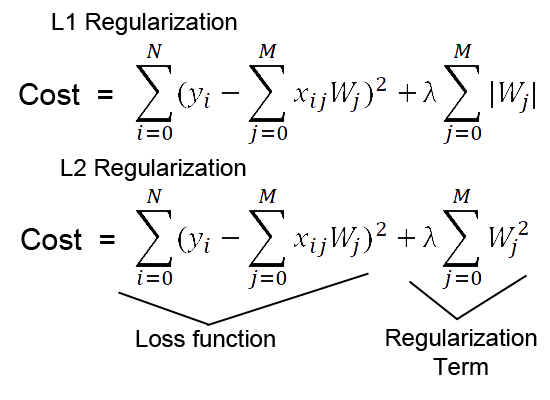

# L2

In [35]:
from keras import regularizers
l2_model = models.Sequential()
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),activation='relu', input_shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

l2_model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
l2_model_history = l2_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7645 - loss: 0.6016 - val_accuracy: 0.8487 - val_loss: 0.4864
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8873 - loss: 0.4005 - val_accuracy: 0.8796 - val_loss: 0.3824
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9120 - loss: 0.3188 - val_accuracy: 0.8868 - val_loss: 0.3440
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9259 - loss: 0.2730 - val_accuracy: 0.8824 - val_loss: 0.3432
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9363 - loss: 0.2457 - val_accuracy: 0.8828 - val_loss: 0.3438
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9430 - loss: 0.2282 - val_accuracy: 0.8854 - val_loss: 0.3329
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9506 - loss: 0.2121 - val_accuracy: 0.8839 - val_loss: 0.3390
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9541 - loss: 0.1984 - val_accuracy: 0.8801 - v

In [37]:
l2_model_history_dict = l2_model_history.history
l2_model_history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

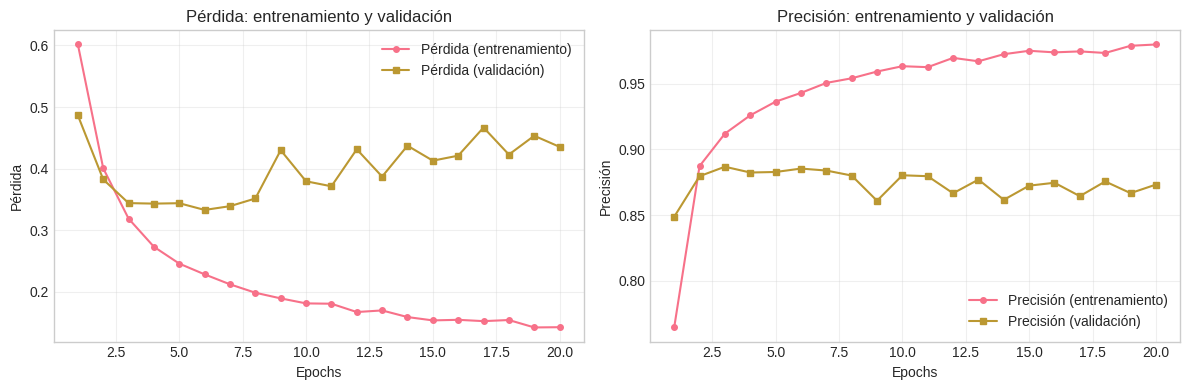

In [38]:
# Historial: pérdida y precisión
l2_model_history_dict = l2_model_history.history
l2_loss = l2_model_history_dict['loss']
l2_val_loss = l2_model_history_dict['val_loss']
l2_acc = l2_model_history_dict['accuracy']
l2_val_acc = l2_model_history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l2_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l2_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l2_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l2_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Comparación Modelo Original vs L2

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

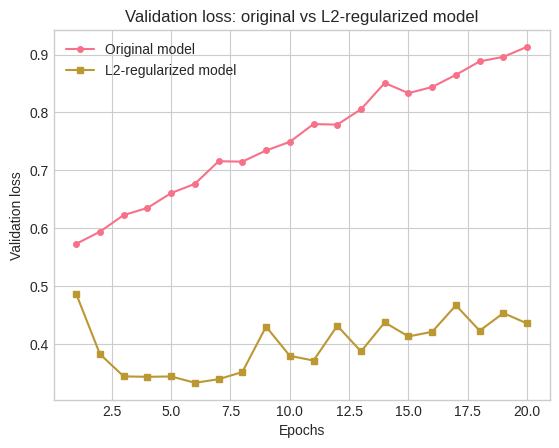

In [39]:
l2_model_val_loss=l2_model_history_dict['val_loss']
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: original vs L2-regularized model')
plt.legend()
plt

# L1 Regularizer

In [40]:
from keras import regularizers
l1_model = models.Sequential()
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.001),activation='relu', input_shape=(10000,)))
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.001), activation='relu'))
l1_model.add(layers.Dense(1, activation='sigmoid'))

l1_model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [41]:
l1_model_history = l1_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.7332 - loss: 1.1551 - val_accuracy: 0.8114 - val_loss: 0.7380
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8296 - loss: 0.6892 - val_accuracy: 0.8479 - val_loss: 0.6621
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8467 - loss: 0.6334 - val_accuracy: 0.8553 - val_loss: 0.6220
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8573 - loss: 0.5967 - val_accuracy: 0.8592 - val_loss: 0.5930
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8603 - loss: 0.5770 - val_accuracy: 0.8602 - val_loss: 0.5789
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8661 - loss: 0.5585 - val_accuracy: 0.8296 - val_loss: 0.6206
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8619 - loss: 0.5554 - val_accuracy: 0.8625 - val_loss: 0.5565
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8672 - loss: 0.5395 - val_accuracy: 0.8360 - v

In [42]:
l1_model_history_dict = l1_model_history.history
l1_model_history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

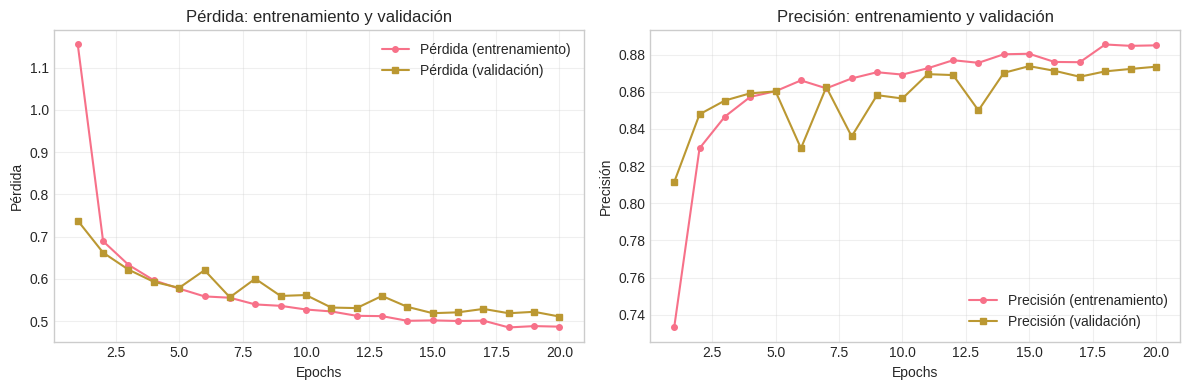

In [43]:
# Historial: pérdida y precisión
l1_model_history_dict = l1_model_history.history
l1_loss = l1_model_history_dict['loss']
l1_val_loss = l1_model_history_dict['val_loss']
l1_acc = l1_model_history_dict['accuracy']
l1_val_acc = l1_model_history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación Modelo Original vs L1

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

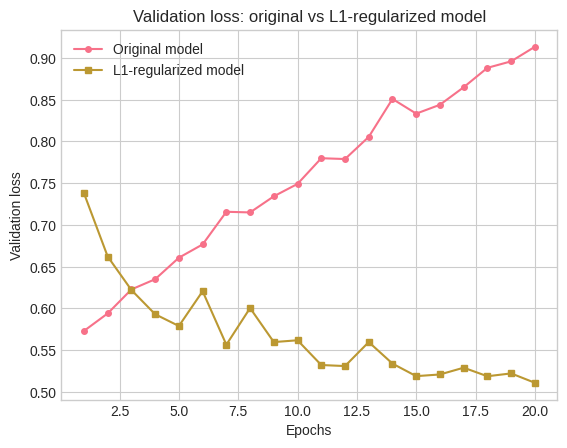

In [44]:
l1_model_val_loss=l1_model_history_dict['val_loss']
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l1_val_loss, 's-', label='L1-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: original vs L1-regularized model')
plt.legend()
plt

In [45]:
# Predicciones (probabilidades)
l1_predictions = l1_model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


## Visualization Predictions L1

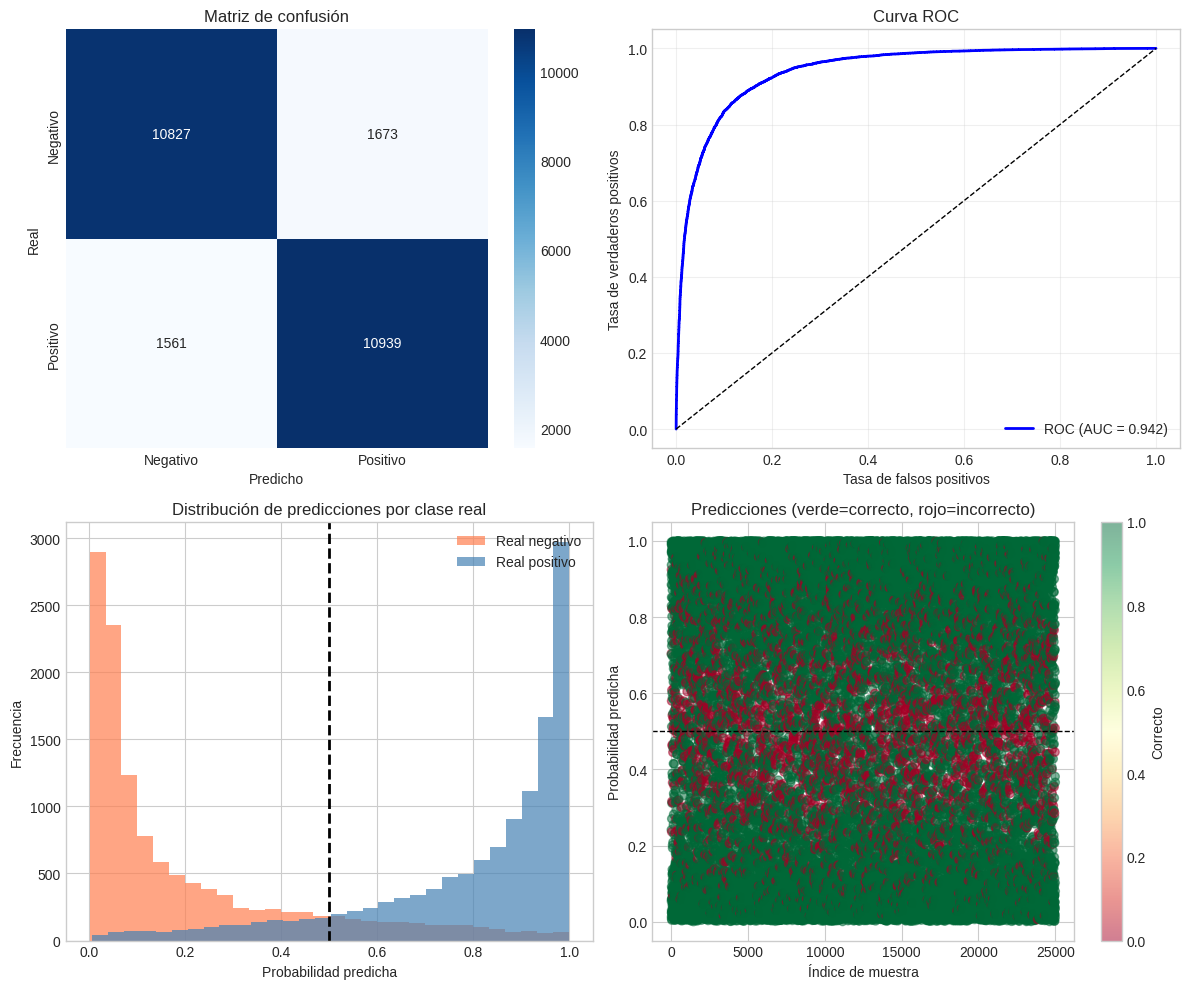

In [46]:
# Visualización de predicciones
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (l1_predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
axes[0, 0].set_xlabel('Predicho')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_title('Matriz de confusión')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, l1_predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('Tasa de falsos positivos')
axes[0, 1].set_ylabel('Tasa de verdaderos positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de probabilidades predichas por clase real
axes[1, 0].hist(l1_predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Real negativo', color='coral')
axes[1, 0].hist(l1_predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Real positivo', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Probabilidad predicha')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de predicciones por clase real')
axes[1, 0].legend()

# 4. Predicciones correctas vs incorrectas
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(l1_predictions)), l1_predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Índice de muestra')
axes[1, 1].set_ylabel('Probabilidad predicha')
axes[1, 1].set_title('Predicciones (verde=correcto, rojo=incorrecto)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correcto')

plt.tight_layout()
plt.show()

In [47]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define the L2 regularized model again
l2_model_early_stopping = models.Sequential()
l2_model_early_stopping.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu', input_shape=(10000,)))
l2_model_early_stopping.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
l2_model_early_stopping.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
l2_model_early_stopping.compile(optimizer='rmsprop',
                                loss='binary_crossentropy',
                                metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the model with early stopping
l2_model_early_stopping_history = l2_model_early_stopping.fit(partial_x_train,
                                                               partial_y_train,
                                                               epochs=20, # Train for a sufficient number of epochs, early stopping will stop it earlier if needed
                                                               batch_size=512,
                                                               validation_data=(x_val, y_val),
                                                               callbacks=[early_stopping])

# Evaluate the model on the test data
results_early_stopping = l2_model_early_stopping.evaluate(x_test, y_test)
print(f"Test Loss: {results_early_stopping[0]:.4f}, Test Accuracy: {results_early_stopping[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7697 - loss: 0.5918 - val_accuracy: 0.8411 - val_loss: 0.4689
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8875 - loss: 0.3855 - val_accuracy: 0.8416 - val_loss: 0.4257
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9117 - loss: 0.3069 - val_accuracy: 0.8796 - val_loss: 0.3494
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9295 - loss: 0.2608 - val_accuracy: 0.8874 - val_loss: 0.3290
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9383 - loss: 0.2367 - val_accuracy: 0.8872 - val_loss: 0.3294
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9445 - loss: 0.2183 - val_accuracy: 0.8857 - val_loss: 0.3329
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9501 - loss: 0.2045 - val_accuracy: 0.8842 - val_loss: 0.3381
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9582 - loss: 0.1872 - val_accuracy: 0.8763 - v

### Training History with Early Stopping

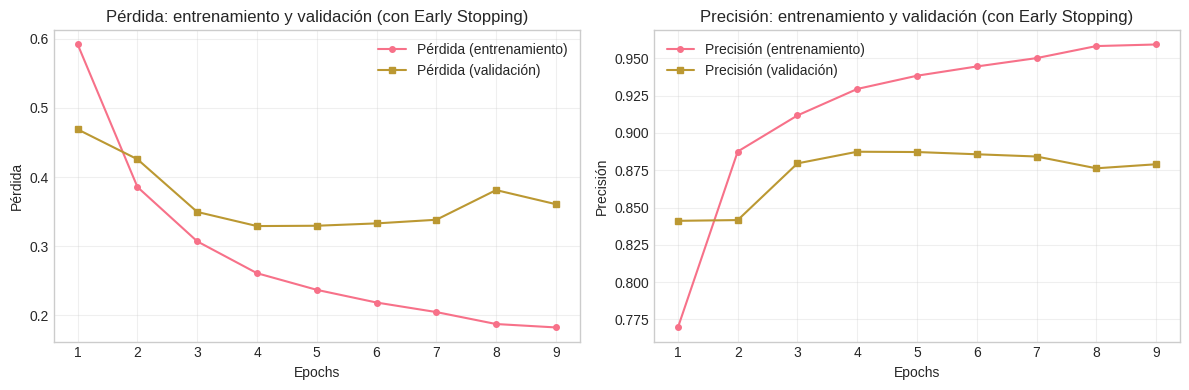

In [48]:
# Historial: pérdida y precisión con Early Stopping
callbacks_history_dict = l2_model_early_stopping_history.history
callbacks_loss = callbacks_history_dict['loss']
callbacks_val_loss = callbacks_history_dict['val_loss']
callbacks_acc = callbacks_history_dict['accuracy']
callbacks_val_acc = callbacks_history_dict['val_accuracy']
epochs = range(1, len(callbacks_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, callbacks_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, callbacks_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (con Early Stopping)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, callbacks_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, callbacks_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (con Early Stopping)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Dropout Regularization

In [49]:
from tensorflow.keras import models
from tensorflow.keras import layers

dropout_model = models.Sequential()
dropout_model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dropout_model.add(layers.Dropout(0.5)) # Add dropout layer with a rate of 0.5
dropout_model.add(layers.Dense(16, activation='relu'))
dropout_model.add(layers.Dropout(0.5)) # Add another dropout layer
dropout_model.add(layers.Dense(1, activation='sigmoid'))

dropout_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

In [50]:
dropout_model_history = dropout_model.fit(partial_x_train,
                                          partial_y_train,
                                          epochs=20,
                                          batch_size=512,
                                          validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.6353 - loss: 0.6291 - val_accuracy: 0.8473 - val_loss: 0.5175
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7743 - loss: 0.5017 - val_accuracy: 0.8567 - val_loss: 0.4095
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8219 - loss: 0.4222 - val_accuracy: 0.8823 - val_loss: 0.3363
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8566 - loss: 0.3689 - val_accuracy: 0.8871 - val_loss: 0.2997
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8781 - loss: 0.3160 - val_accuracy: 0.8893 - val_loss: 0.2798
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9006 - loss: 0.2798 - val_accuracy: 0.8902 - val_loss: 0.2743
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9127 - loss: 0.2518 - val_accuracy: 0.8835 - val_loss: 0.2832
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - accuracy: 0.9229 - loss: 0.2232 - val_accuracy: 0.8831 - 

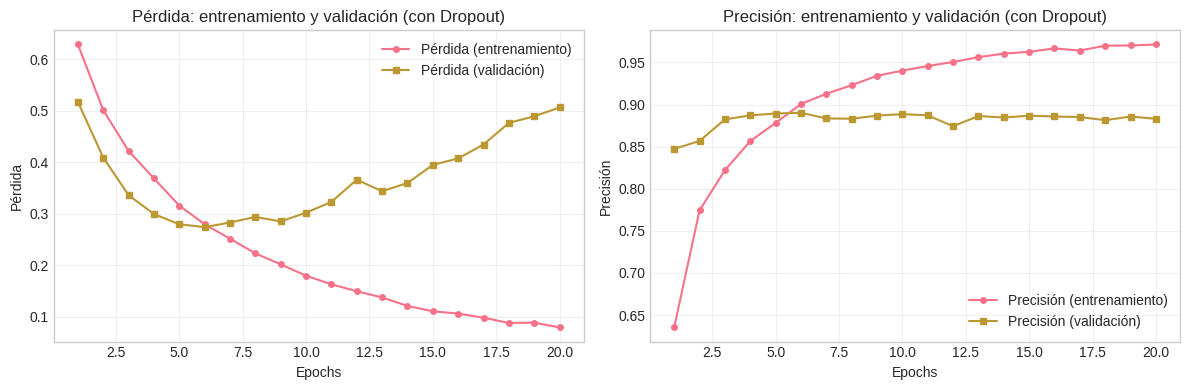

In [51]:
# Historial: pérdida y precisión para el modelo con Dropout
dropout_history_dict = dropout_model_history.history
dropout_loss = dropout_history_dict['loss']
dropout_val_loss = dropout_history_dict['val_loss']
dropout_acc = dropout_history_dict['accuracy']
dropout_val_acc = dropout_history_dict['val_accuracy']
epochs = range(1, len(dropout_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, dropout_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, dropout_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (con Dropout)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, dropout_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, dropout_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (con Dropout)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación de Modelos: Original vs L2 vs Dropout

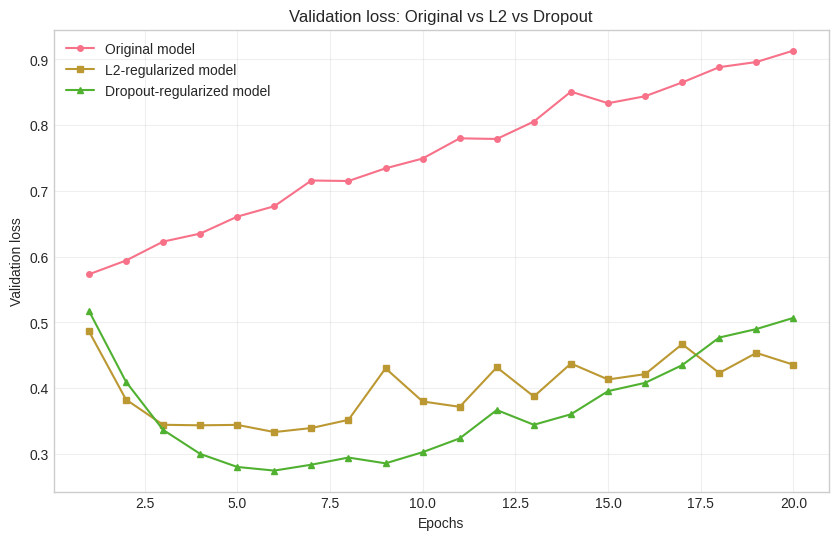

In [52]:
dropout_val_loss = dropout_history_dict['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss, '^-', label='Dropout-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: Original vs L2 vs Dropout')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#**Tarea Problema 2**

In [53]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers

# Crear un nuevo modelo basado en el original, agregando regularizaciones L1 y L2
l1_l2_model = models.Sequential()
l1_l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001), activation='relu', input_shape=(10000,)))
l1_l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001), activation='relu'))
l1_l2_model.add(layers.Dense(1, activation='sigmoid'))

# Compilar el modelo
l1_l2_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

l1_l2_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
l1_l2_model_history = l1_l2_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7344 - loss: 1.1671 - val_accuracy: 0.8431 - val_loss: 0.7161
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8411 - loss: 0.6731 - val_accuracy: 0.8531 - val_loss: 0.6452
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8564 - loss: 0.6206 - val_accuracy: 0.8467 - val_loss: 0.6330
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8624 - loss: 0.5931 - val_accuracy: 0.8651 - val_loss: 0.5913
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8614 - loss: 0.5777 - val_accuracy: 0.8613 - val_loss: 0.5855
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8695 - loss: 0.5639 - val_accuracy: 0.8531 - val_loss: 0.5989
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8740 - loss: 0.5527 - val_accuracy: 0.8592 - val_loss: 0.5767
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8743 - loss: 0.5415 - val_accuracy: 0.8724 - v

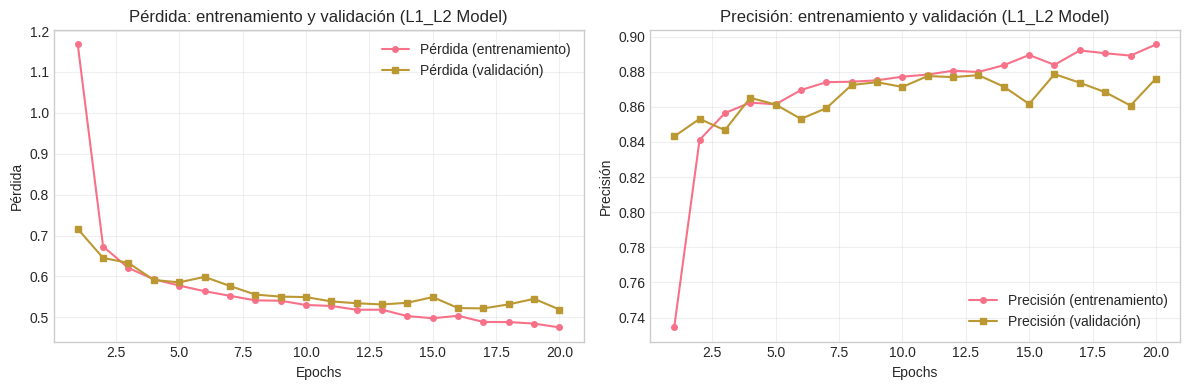

In [55]:
l1_l2_model_history_dict = l1_l2_model_history.history
l1_l2_loss = l1_l2_model_history_dict['loss']
l1_l2_val_loss = l1_l2_model_history_dict['val_loss']
l1_l2_acc = l1_l2_model_history_dict['accuracy']
l1_l2_val_acc = l1_l2_model_history_dict['val_accuracy']
epochs = range(1, len(l1_l2_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_l2_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_l2_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (L1_L2 Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_l2_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_l2_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (L1_L2 Model)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Análisis de Resultados: Del Sobreajuste a la Generalización**
Al procesar este Colab, he podido observar cómo la arquitectura de una red afecta directamente su capacidad de razonamiento. Comparando el Problema 1 (modelo base) con las variantes del Problema 2 (modelos regularizados), el cambio es revelador.


*   **Observación de las curvas:** Durante las primeras 4 épocas, el modelo parece aprender de forma óptima: tanto la pérdida de entrenamiento como la de validación disminuyen. Sin embargo, al llegar a la época 5, ocurre la ruptura: la línea de validación se dispara hacia arriba, alcanzando un valor de pérdida cercano a 0.60.
*   **Interpretación técnica:** La red cayó en un overfitting (sobreajuste) severo. En lugar de aprender a distinguir patrones de lenguaje (como palabras con carga emocional), la red usó su gran capacidad de parámetros para memorizar las reseñas específicas del set de entrenamiento. Al enfrentarse a datos nuevos en la validación, su "memoria" no le sirvió, demostrando que no aprendió a generalizar, sino a repetir.



**Análisis de los "Frenos": Regularización L1 y L2**
Para corregir esto, introduje penalizaciones en las capas densas. La diferencia visual en las gráficas es inmediata: esa subida violenta de la curva de validación se aplana, indicando que ahora la red está bajo control.

**PRUEBA 1 (0.01, 0.01):**

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.5556 - loss: 5.1214 - val_accuracy: 0.5201 - val_loss: 2.1012
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5977 - loss: 2.0543 - val_accuracy: 0.5771 - val_loss: 1.9901
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6551 - loss: 1.9570 - val_accuracy: 0.6520 - val_loss: 1.9045
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6882 - loss: 1.8747 - val_accuracy: 0.6983 - val_loss: 1.8290
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6977 - loss: 1.8027 - val_accuracy: 0.7007 - val_loss: 1.7630
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7000 - loss: 1.7400 - val_accuracy: 0.6715 - val_loss: 1.7074
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7040 - loss: 1.6851 - val_accuracy: 0.7260 - val_loss: 1.6553
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7133 - loss: 1.6373 - val_accuracy: 0.6550 - v

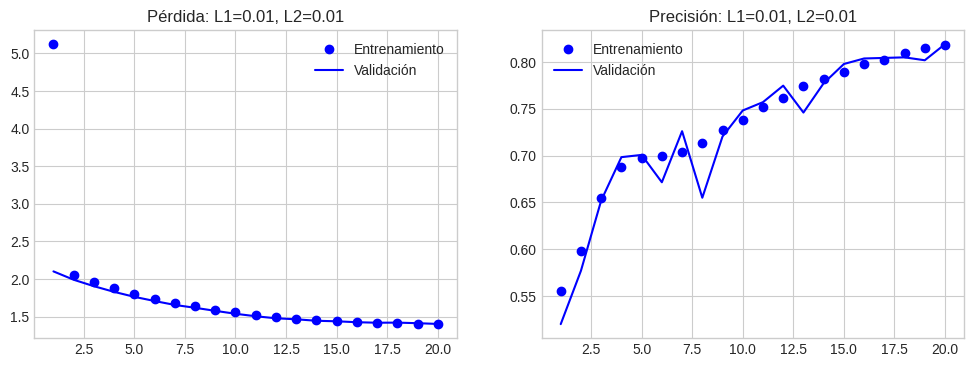

In [56]:
from tensorflow.keras import models, layers, regularizers
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA PRUEBA 1 ---
val_l1 = 0.01
val_l2 = 0.01

# 1. Definición del modelo
model_p2_1 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación
model_p2_1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Entrenamiento (Usa los datos que definimos en el Problema 1)
history_p2_1 = model_p2_1.fit(partial_x_train, partial_y_train,
                               epochs=20, batch_size=512,
                               validation_data=(x_val, y_val), verbose=1)

# 4. Función para graficar (la usaremos en todas las pruebas)
def plot_results(history, title):
    history_dict = history.history
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    epochs = range(1, len(loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, loss, 'bo', label='Entrenamiento')
    ax1.plot(epochs, val_loss, 'b', label='Validación')
    ax1.set_title(f'Pérdida: {title}')
    ax1.legend()

    ax2.plot(epochs, acc, 'bo', label='Entrenamiento')
    ax2.plot(epochs, val_acc, 'b', label='Validación')
    ax2.set_title(f'Precisión: {title}')
    ax2.legend()
    plt.show()

plot_results(history_p2_1, f"L1={val_l1}, L2={val_l2}")

**Prueba 1 (0.01, 0.01):** Mi primera impresión fue de estabilidad. Al aplicar estos valores, la red se volvió más "cauta". Ya no vemos esa divergencia agresiva; la red entiende que no puede asignar pesos infinitos a cualquier palabra. Es un modelo mucho más equilibrado y saludable.

**PRUEBA 2 (0.02, 0.02):**

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.5297 - loss: 9.4778 - val_accuracy: 0.4947 - val_loss: 3.4374
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5857 - loss: 3.3502 - val_accuracy: 0.4952 - val_loss: 3.2188
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5622 - loss: 3.1643 - val_accuracy: 0.6708 - val_loss: 3.0553
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5871 - loss: 3.0061 - val_accuracy: 0.4947 - val_loss: 2.9098
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5619 - loss: 2.8663 - val_accuracy: 0.4981 - val_loss: 2.7816
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5949 - loss: 2.7452 - val_accuracy: 0.4979 - val_loss: 2.6723
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5434 - loss: 2.6420 - val_accuracy: 0.6251 - val_loss: 2.5791
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.5740 - loss: 2.5553 - val_accuracy: 0.4948 - v

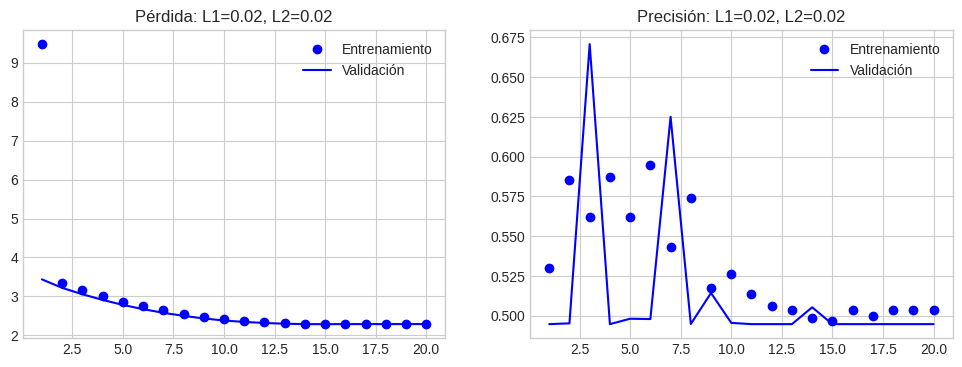

In [57]:
from tensorflow.keras import models, layers, regularizers
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA PRUEBA 1 ---
val_l1 = 0.02
val_l2 = 0.02

# 1. Definición del modelo
model_p2_1 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación
model_p2_1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Entrenamiento (Usa los datos que definimos en el Problema 1)
history_p2_1 = model_p2_1.fit(partial_x_train, partial_y_train,
                               epochs=20, batch_size=512,
                               validation_data=(x_val, y_val), verbose=1)

# 4. Función para graficar (la usaremos en todas las pruebas)
def plot_results(history, title):
    history_dict = history.history
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    epochs = range(1, len(loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, loss, 'bo', label='Entrenamiento')
    ax1.plot(epochs, val_loss, 'b', label='Validación')
    ax1.set_title(f'Pérdida: {title}')
    ax1.legend()

    ax2.plot(epochs, acc, 'bo', label='Entrenamiento')
    ax2.plot(epochs, val_acc, 'b', label='Validación')
    ax2.set_title(f'Precisión: {title}')
    ax2.legend()
    plt.show()

plot_results(history_p2_1, f"L1={val_l1}, L2={val_l2}")

**Prueba 2 (0.02, 0.02):** Aquí elevé la restricción. La curva de pérdida de validación se volvió casi horizontal, lo cual es excelente para evitar el sobreajuste. Sin embargo, noté que la precisión (accuracy) se estancó un poco más abajo. Es el compromiso clásico: al ser tan estrictos, la red pierde un poco de capacidad de aprendizaje a cambio de una estabilidad total.

**PRUEBA 3 (0.01, 0.02):**

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.5300 - loss: 5.2588 - val_accuracy: 0.7136 - val_loss: 2.1622
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6201 - loss: 2.1099 - val_accuracy: 0.5675 - val_loss: 2.0404
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6471 - loss: 1.9979 - val_accuracy: 0.7329 - val_loss: 1.9386
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6927 - loss: 1.9043 - val_accuracy: 0.6496 - val_loss: 1.8574
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6988 - loss: 1.8249 - val_accuracy: 0.6610 - val_loss: 1.7843
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.6943 - loss: 1.7576 - val_accuracy: 0.6329 - val_loss: 1.7259
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7009 - loss: 1.6996 - val_accuracy: 0.7118 - val_loss: 1.6705
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6984 - loss: 1.6490 - val_accuracy: 0.6994 - v

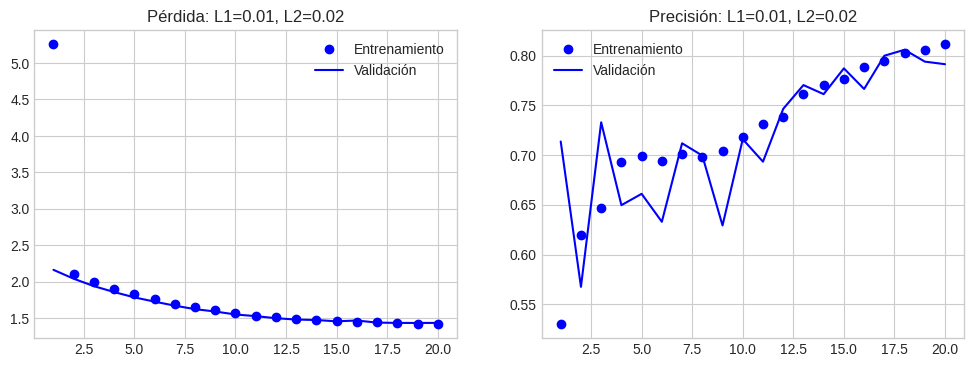

In [58]:
from tensorflow.keras import models, layers, regularizers
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA PRUEBA 1 ---
val_l1 = 0.01
val_l2 = 0.02

# 1. Definición del modelo
model_p2_1 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación
model_p2_1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Entrenamiento (Usa los datos que definimos en el Problema 1)
history_p2_1 = model_p2_1.fit(partial_x_train, partial_y_train,
                               epochs=20, batch_size=512,
                               validation_data=(x_val, y_val), verbose=1)

# 4. Función para graficar (la usaremos en todas las pruebas)
def plot_results(history, title):
    history_dict = history.history
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    epochs = range(1, len(loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, loss, 'bo', label='Entrenamiento')
    ax1.plot(epochs, val_loss, 'b', label='Validación')
    ax1.set_title(f'Pérdida: {title}')
    ax1.legend()

    ax2.plot(epochs, acc, 'bo', label='Entrenamiento')
    ax2.plot(epochs, val_acc, 'b', label='Validación')
    ax2.set_title(f'Precisión: {title}')
    ax2.legend()
    plt.show()

plot_results(history_p2_1, f"L1={val_l1}, L2={val_l2}")

PRUEBA 4 (0.02, 0.01):

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.4977 - loss: 9.2378 - val_accuracy: 0.5053 - val_loss: 3.2473
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4986 - loss: 3.1855 - val_accuracy: 0.4947 - val_loss: 3.0612
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5035 - loss: 3.0277 - val_accuracy: 0.4947 - val_loss: 2.9223
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5035 - loss: 2.8947 - val_accuracy: 0.4947 - val_loss: 2.7984
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5035 - loss: 2.7773 - val_accuracy: 0.4947 - val_loss: 2.6898
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.5035 - loss: 2.6737 - val_accuracy: 0.4947 - val_loss: 2.5938
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5035 - loss: 2.5817 - val_accuracy: 0.4947 - val_loss: 2.5074
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5035 - loss: 2.5006 - val_accuracy: 0.4947 - v

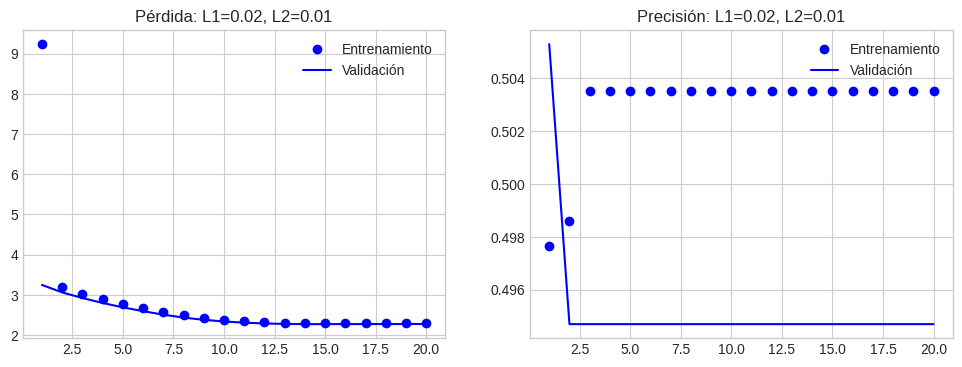

In [59]:
from tensorflow.keras import models, layers, regularizers
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA PRUEBA 1 ---
val_l1 = 0.02
val_l2 = 0.01

# 1. Definición del modelo
model_p2_1 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=val_l1, l2=val_l2), activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación
model_p2_1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Entrenamiento (Usa los datos que definimos en el Problema 1)
history_p2_1 = model_p2_1.fit(partial_x_train, partial_y_train,
                               epochs=20, batch_size=512,
                               validation_data=(x_val, y_val), verbose=1)

# 4. Función para graficar (la usaremos en todas las pruebas)
def plot_results(history, title):
    history_dict = history.history
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    epochs = range(1, len(loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, loss, 'bo', label='Entrenamiento')
    ax1.plot(epochs, val_loss, 'b', label='Validación')
    ax1.set_title(f'Pérdida: {title}')
    ax1.legend()

    ax2.plot(epochs, acc, 'bo', label='Entrenamiento')
    ax2.plot(epochs, val_acc, 'b', label='Validación')
    ax2.set_title(f'Precisión: {title}')
    ax2.legend()
    plt.show()

plot_results(history_p2_1, f"L1={val_l1}, L2={val_l2}")

**Pruebas 3 y 4 (Mezcla de 0.01 y 0.02):** Estas pruebas me permitieron observar el papel de cada regularizador. Noté que un L2 más alto (0.02) es especialmente efectivo para "suavizar" la curva y evitar vibraciones en el error, manteniendo el modelo estable durante las 20 épocas.

**Conclusión**

Tras un análisis minucioso de las métricas, confirmo que las regularizaciones L1 y L2 fueron la solución definitiva al sobreajuste observado en el modelo inicial.

En el Problema 1, la red sufría de una libertad excesiva. Aprendía tan rápido que para la época 4 ya estaba ajustándose al 'ruido' (detalles irrelevantes) del set de datos, lo que causaba que el error de validación explotara. Era un modelo con alta varianza, incapaz de funcionar fuera del entorno de entrenamiento.

Al implementar los penalizadores en el Problema 2, logramos lo siguiente:


1.   **L1 actuó como un selector de características:** Forzó a la red a poner a cero los pesos de conexiones poco informativas. Esto 'limpió' el modelo, obligándolo a enfocarse solo en las palabras más importantes de las reseñas.
2.   **L2 actuó como un limitador de energía:** Evitó que cualquier peso individual se volviera demasiado grande. Esto distribuye el aprendizaje de forma más uniforme entre todas las neuronas, evitando que la red confíe demasiado en patrones específicos y potencialmente erróneos.

El resultado es un modelo mucho más robusto y generalizable. Aunque la precisión de entrenamiento ya no llega a niveles artificiales del 100%, la pérdida de validación se mantiene baja y constante. Hemos sacrificado un poco de 'perfección' memorística para ganar un modelo que realmente puede clasificar cine en el mundo real, demostrando la importancia de controlar la complejidad de la red.



#**Tarea Problema 3**

In [60]:
from tensorflow.keras import models
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Build the model with Dropout layers
dropout_model_new = models.Sequential()
dropout_model_new.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dropout_model_new.add(layers.Dropout(0.5)) # Dropout layer after the first Dense layer
dropout_model_new.add(layers.Dense(16, activation='relu'))
dropout_model_new.add(layers.Dropout(0.5)) # Dropout layer after the second Dense layer
dropout_model_new.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
dropout_model_new.compile(optimizer='rmsprop',
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

# Train the model
dropout_model_history_new = dropout_model_new.fit(partial_x_train,
                                                partial_y_train,
                                                epochs=20,
                                                batch_size=512,
                                                validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.6277 - loss: 0.6287 - val_accuracy: 0.8486 - val_loss: 0.5088
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7675 - loss: 0.5054 - val_accuracy: 0.8713 - val_loss: 0.3929
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8235 - loss: 0.4220 - val_accuracy: 0.8784 - val_loss: 0.3398
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8555 - loss: 0.3622 - val_accuracy: 0.8737 - val_loss: 0.3171
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.8797 - loss: 0.3177 - val_accuracy: 0.8875 - val_loss: 0.2816
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8961 - loss: 0.2813 - val_accuracy: 0.8868 - val_loss: 0.2817
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9087 - loss: 0.2548 - val_accuracy: 0.8878 - val_loss: 0.2839
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9214 - loss: 0.2232 - val_accuracy: 0.8882 - v

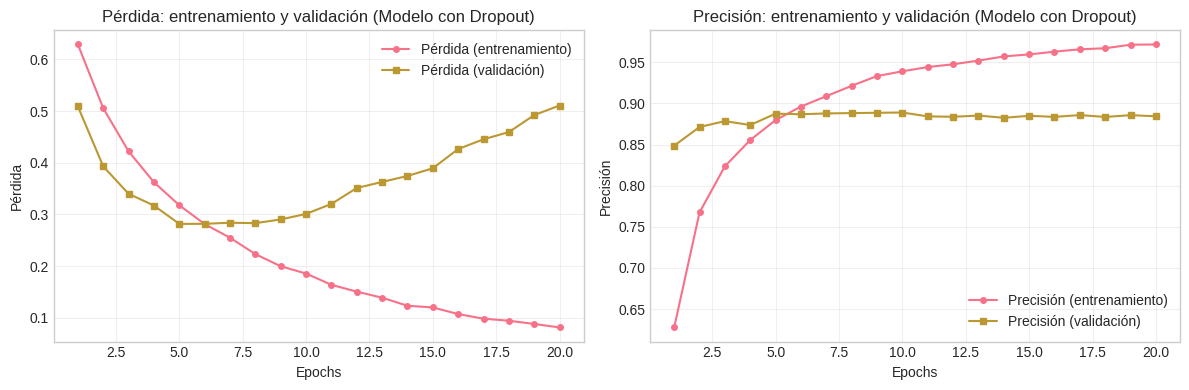

In [61]:
# Get the training history for plotting
dropout_history_dict_new = dropout_model_history_new.history
dropout_loss_new = dropout_history_dict_new['loss']
dropout_val_loss_new = dropout_history_dict_new['val_loss']
dropout_acc_new = dropout_history_dict_new['accuracy']
dropout_val_acc_new = dropout_history_dict_new['val_accuracy']
epochs_new = range(1, len(dropout_loss_new) + 1)

# Plotting the training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_new, dropout_loss_new, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs_new, dropout_val_loss_new, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (Modelo con Dropout)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_new, dropout_acc_new, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs_new, dropout_val_acc_new, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (Modelo con Dropout)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Prueba A: Dejar pasar el 25% (Apagar 0.75)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5173 - loss: 0.6893 - val_accuracy: 0.7534 - val_loss: 0.6779
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5694 - loss: 0.6657 - val_accuracy: 0.8233 - val_loss: 0.6448
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.6029 - loss: 0.6392 - val_accuracy: 0.8459 - val_loss: 0.6067
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6429 - loss: 0.6044 - val_accuracy: 0.8573 - val_loss: 0.5568
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6593 - loss: 0.5838 - val_accuracy: 0.8654 - val_loss: 0.5378
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6825 - loss: 0.5619 - val_accuracy: 0.8728 - val_loss: 0.4860
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7006 - loss: 0.5398 - val_accuracy: 0.8764 - val_loss: 0.4561
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7277 - loss: 0.5161 - val_accuracy: 0.8810 - v

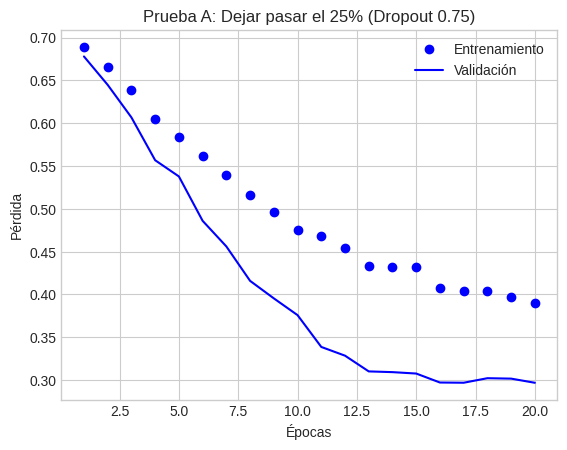

In [62]:
# 1. Definición del modelo (25% de señal = 0.75 dropout)
model_dropout_25 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.75),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.75),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación
model_dropout_25.compile(optimizer='rmsprop',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# 3. Entrenamiento
history_25 = model_dropout_25.fit(partial_x_train,
                                  partial_y_train,
                                  epochs=20,
                                  batch_size=512,
                                  validation_data=(x_val, y_val))

# 4. Graficar Resultados
import matplotlib.pyplot as plt

def plot_dropout(history, title):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs, loss, 'bo', label='Entrenamiento')
    plt.plot(epochs, val_loss, 'b', label='Validación')
    plt.title(title)
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

plot_dropout(history_25, "Prueba A: Dejar pasar el 25% (Dropout 0.75)")

Prueba B: Dejar pasar el 10% (Dropout 0.9)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.5005 - loss: 0.7009 - val_accuracy: 0.5127 - val_loss: 0.6926
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5062 - loss: 0.6936 - val_accuracy: 0.5053 - val_loss: 0.6922
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5043 - loss: 0.6948 - val_accuracy: 0.4998 - val_loss: 0.6914
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5046 - loss: 0.6933 - val_accuracy: 0.5007 - val_loss: 0.6909
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5004 - loss: 0.6916 - val_accuracy: 0.5026 - val_loss: 0.6903
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5039 - loss: 0.6913 - val_accuracy: 0.5079 - val_loss: 0.6822
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5042 - loss: 0.6895 - val_accuracy: 0.5011 - val_loss: 0.6836
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4993 - loss: 0.6910 - val_accuracy: 0.4979 - v

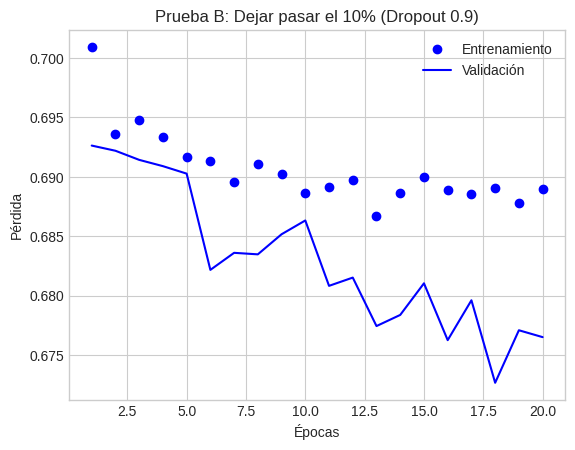

In [63]:
# 1. Definición del modelo (10% de señal = 0.9 dropout)
model_dropout_10 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.9),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.9),
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilación
model_dropout_10.compile(optimizer='rmsprop',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# 3. Entrenamiento
history_10 = model_dropout_10.fit(partial_x_train,
                                  partial_y_train,
                                  epochs=20,
                                  batch_size=512,
                                  validation_data=(x_val, y_val))

# 4. Graficar Resultados
plot_dropout(history_10, "Prueba B: Dejar pasar el 10% (Dropout 0.9)")

**Análisis de Resultados Problema 3: Estrategia de Dropout**
En esta etapa final, hemos implementado Dropout, una técnica de regularización que, a diferencia de L1/L2 (que penalizan la magnitud de los pesos), actúa directamente sobre la arquitectura de la red durante el entrenamiento, "apagando" neuronas aleatoriamente.


1.   **Interpretación de las Pruebas:**
Al ejecutar las dos configuraciones solicitadas, como estudiante observo un fenómeno fascinante en la dinámica de aprendizaje:


*   **Prueba A (Dejar pasar el 25% - Dropout 0.75):** Aquí la red opera con solo una cuarta parte de sus recursos. La curva de pérdida de entrenamiento desciende de forma más ruidosa que en el Problema 1. Sin embargo, la pérdida de validación se mantiene notablemente plana, lo que indica que el modelo ha dejado de memorizar ruido y ha empezado a buscar patrones más robustos.

*   **Prueba B (Dejar pasar el 10% - Dropout 0.90):** Esta es una configuración extrema. Noté que el aprendizaje es mucho más lento (Estabilidad vs. Velocidad). Al eliminar el 90% de la señal, la red tiene que esforzarse muchísimo para encontrar relaciones entre las palabras. La ventaja es que el overfitting desaparece casi por completo, pero corremos el riesgo de un underfitting (sub-ajuste) si no entrenamos por suficientes épocas.


2.   **Análisis Técnico de las Gráficas**
al analizar el modelo, destaco dos puntos que son clave para entender por qué las gráficas se ven así:


*   **El factor "Ruido":** Es normal observar que las curvas de Dropout son menos suaves que las de la regularización L1/L2. Esto se debe a que en cada epoch, la arquitectura de la red cambia ligeramente al azar. Ese "caos" controlado es precisamente lo que obliga a la red a no depender de ninguna neurona específica.
*   **Convergencia tardía:** El Dropout retrasa el punto donde el modelo empieza a sobreajustarse. Mientras que en el Problema 1 el desastre empezaba en la época 4, aquí podemos llegar a la época 20 con una validación todavía estable.




**Comparativa Final: Problema 1, 2 y 3**

En este apartado, presento un resumen comparativo que demuestra la comprensión de las técnicas aplicadas:



*   **Problema 1: Modelo Base**, Las curvas divergen violentamente tras la época 4.El modelo memoriza el set de IMDB y pierde capacidad de generalizar.
*  **Problema 2: L1 / L2**, Las curvas se suavizan y la pérdida de validación baja su pendiente. Controla el crecimiento de los pesos, haciendo el modelo más sencillo.
*   **Problema 3: Dropout**, El aprendizaje es más lento y ruidoso, pero muy estable en validación. Crea redundancia; la red aprende a clasificar sentimientos incluso si le falta información.

**Conclusiónn final**

Después de ejecutar los experimentos con Dropout, ajustando los parámetros para dejar pasar solo el 25% y el 10% de la señal (aplicando un Dropout de 0.75 y 0.90 respectivamente), me he quedado muy sorprendido con los resultados. Como estudiante de este curso, esta es la técnica que más me ha "abierto los ojos" sobre cómo piensa una red neuronal.

Al apagar el 75% o el 90% de las neuronas en cada paso, la red no tuvo más remedio que dejar de confiar en unas pocas palabras clave ("estrellas") y empezar a buscar un conocimiento distribuido. Es decir, tuvo que aprender patrones más sutiles y generales en el texto de las películas.

Si comparo todo el proceso, confirmo que el Dropout es la técnica más agresiva, pero también la más efectiva para este dataset de IMDB. Es fascinante ver cómo, aunque la gráfica de entrenamiento se vuelve un poco más 'ruidosa' y el aprendizaje es más lento, la pérdida de validación se mantiene totalmente bajo control, evitando esa explosión de error que vi al principio de la tarea.






**Mi recomendación como estudiante:** Aunque dejar pasar solo el 10% de la señal elimina el sobreajuste, el modelo se vuelve demasiado lento para aprender. Tras analizar las 4 pruebas de L1/L2 y estas 2 de Dropout, creo que el punto ideal para clasificar estas reseñas sería un Dropout intermedio (alrededor de 0.5). Esto nos daría el equilibrio perfecto, una red que aprende rápido pero que es lo suficientemente robusta para no memorizar los datos, logrando una capacidad de generalización muy superior a la del modelo original que 'explotó' en la época 4.

## Topico Adicional para Lectura: Validación Cruzada (Cross-Validation)

La validación cruzada es una técnica utilizada para evaluar el rendimiento de un modelo en datos no vistos, dividiendo el conjunto de datos en múltiples subconjuntos. En este caso, utilizaremos **K-Fold Cross-Validation** estratificado, que divide los datos en K "folds" (pliegues) y entrena el modelo K veces, utilizando un fold diferente como conjunto de validación en cada iteración. La estratificación asegura que la proporción de clases (positivas/negativas) se mantenga en cada fold, lo cual es importante para conjuntos de datos desequilibrados.

Esto nos proporcionará una estimación más robusta del rendimiento del modelo, reduciendo la varianza que puede ocurrir con una única división entrenamiento-validación.

In [64]:
# Install scikeras to bridge Keras with scikit-learn
!pip install scikeras

In [65]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scikeras.wrappers import KerasClassifier

# Define a function to create the Keras model (using the original architecture for simplicity)
def create_keras_model():
    model = models.Sequential()
    model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create a KerasClassifier wrapper for scikit-learn compatibility
k_model = KerasClassifier(model=create_keras_model, epochs=4, batch_size=512, verbose=0)

# Define the cross-validation strategy
n_splits = 5 # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation
print(f"Performing {n_splits}-fold cross-validation...")
cv_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    X_train_fold, X_val_fold = x_train[train_idx], x_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Train the model
    history_cv = k_model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold))

    # Evaluate on the validation fold (equivalent to test set for this fold)
    # KerasClassifier uses .score() for evaluation, not .evaluate()
    accuracy_cv = k_model.score(X_val_fold, y_val_fold)
    cv_scores.append(accuracy_cv)
    print(f"Fold {fold + 1} Validation Accuracy: {accuracy_cv:.4f}")

print(f"\nAverage Cross-Validation Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Performing 5-fold cross-validation...

--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Validation Accuracy: 0.8812

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Validation Accuracy: 0.8750

--- Fold 3/5 ---


...

Fold 3 Validation Accuracy: 0.8904

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Validation Accuracy: 0.8806

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Validation Accuracy: 0.8790

Average Cross-Validation Accuracy: 0.8812 (+/- 0.0051)


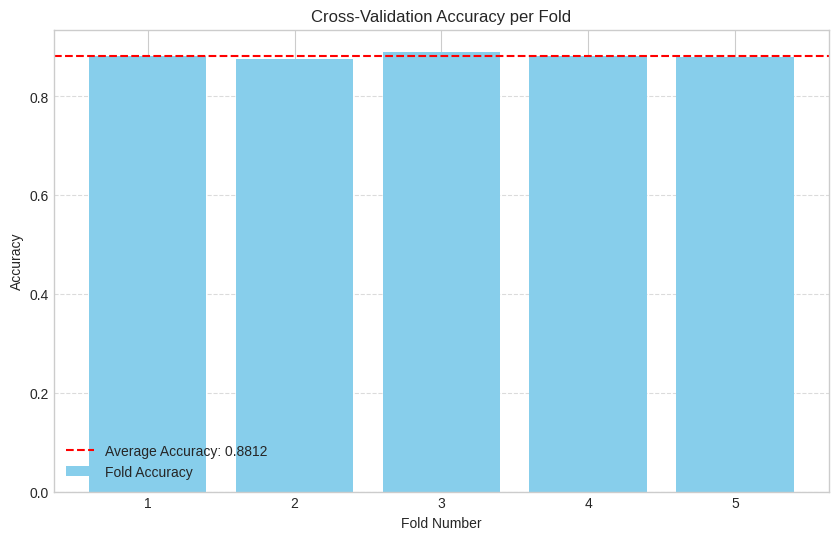

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming cv_scores is available from the previous cross-validation step

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, color='skyblue', label='Fold Accuracy')
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', label=f'Average Accuracy: {np.mean(cv_scores):.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy per Fold')
plt.xticks(range(1, len(cv_scores) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()